# 02. Baseline-модели «из коробки» (без feature engineering)

**Цель:** зафиксировать нижнюю планку качества, используя ТОЛЬКО сырые OHLCV-колонки (`Open, High, Low, Close, Volume`). Никаких технических индикаторов, никаких трансформаций — стандартные модели sklearn с дефолтными параметрами.

**Зачем такой baseline.** Сырая `Close` нестационарна (см. EDA, раздел 6) — линейная модель и KNN не должны находить устойчивого сигнала. Если фичи из `01_eda` действительно несут информацию, в `03_experiments` мы должны заметно обойти эти числа.

**Вся логика — в `src/modeling.py`.** Этот ноутбук — тонкая обёртка: загрузка → запуск → визуализация.

**Главная метрика — Precision** при пороге 0.5 (см. EDA, раздел 8). Вспомогательные — ROC-AUC, PR-AUC, trade_freq.

**Сплит** (см. EDA, раздел 7):
- Train: 2010-01-01 … 2021-12-31
- Val: 2022-01-01 … 2023-12-31
- Test: 2024-01-01 … 2024-12-31 — **не трогаем** (для финального сравнения в `03_experiments`)

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modeling import (
    RAW_FEATURES,
    build_raw_dataset,
    time_split,
    run_baseline_holdout,
    run_baseline_cv,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:.4f}'.format)

TICKERS = ['^GSPC', 'AAPL', 'MSFT', 'JPM', 'XOM']
PRIMARY = '^GSPC'
START, END = '2010-01-01', '2024-12-31'
RANDOM_SEED = 42

## 1. Датасет: только OHLCV + Target

Никаких технических индикаторов. `build_raw_dataset` = `load_ohlcv` + `build_target` + `dropna`.

In [2]:
df = build_raw_dataset(PRIMARY, START, END)
print(f'shape: {df.shape}')
print(f'columns: {list(df.columns)}')
print(f'range:   {df.index.min().date()} .. {df.index.max().date()}')
df.head()

shape: (3772, 6)
columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Target']
range:   2010-01-04 .. 2024-12-27


,Open,High,Low,Close,Volume,Target
Date,,,,,,
2010-01-04,1116.5601,1133.8700,1116.5601,1132.9900,3991400000,1.0000
2010-01-05,1132.6600,1136.6300,1129.6600,1136.5200,2491020000,1.0000
2010-01-06,1135.7100,1139.1899,1133.9500,1137.1400,4972660000,1.0000
2010-01-07,1136.2700,1142.4600,1131.3199,1141.6899,5270680000,1.0000
2010-01-08,1140.5200,1145.3900,1136.2200,1144.9800,4389590000,1.0000


In [3]:
train, val, test = time_split(df)
split_summary = pd.DataFrame({
    'rows':  [len(train), len(val), len(test)],
    'start': [train.index.min().date(), val.index.min().date(), test.index.min().date()],
    'end':   [train.index.max().date(), val.index.max().date(), test.index.max().date()],
    'mean(Target)': [train['Target'].mean(), val['Target'].mean(), test['Target'].mean()],
}, index=['train', 'val', 'test'])
split_summary

,rows,start,end,mean(Target)
train,3021,2010-01-04,2021-12-31,0.5521
val,501,2022-01-03,2023-12-29,0.4870
test,250,2024-01-02,2024-12-27,0.5720


## 2. Holdout: train → val

Запускаем 5 моделей «из коробки»:
- `Dummy (stratified)` — случайные ответы по распределению классов.
- `LogReg` (`StandardScaler` + `class_weight='balanced'`).

Все с дефолтными гиперпараметрами

In [4]:
holdout_results = run_baseline_holdout(PRIMARY, START, END, random_state=RANDOM_SEED)
holdout_results.sort_values('precision', ascending=False).round(4)

,precision,recall,f1,roc_auc,pr_auc,trade_freq,n_samples
model,,,,,,,
Dummy (stratified),0.4926,0.5492,0.5194,0.5061,0.4901,0.5429,501
LogReg (raw OHLCV),0.4914,0.8197,0.6144,0.4814,0.4715,0.8124,501


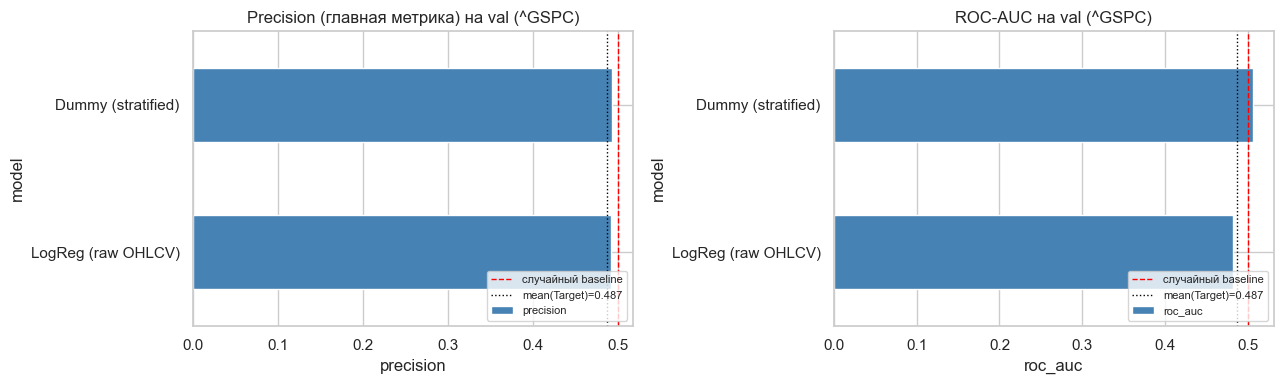

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in zip(
    axes, ['precision', 'roc_auc'], ['Precision (главная метрика)', 'ROC-AUC']
):
    holdout_results[metric].sort_values().plot(
        kind='barh', ax=ax, color='steelblue'
    )
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='случайный baseline')
    ax.axvline(
        val['Target'].mean(), color='black', linestyle=':',
        linewidth=1, label=f"mean(Target)={val['Target'].mean():.3f}"
    )
    ax.set_title(f'{title} на val ({PRIMARY})')
    ax.set_xlabel(metric); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 3. TimeSeriesSplit CV (n_splits=5)

Holdout — это один разрез. CV по 5 fold'ам с растущим train-окном (без shuffle, см. EDA, раздел 7) показывает разброс качества по разным режимам рынка. Если precision_std велик — значит модель нестабильна.

In [6]:
cv_results = run_baseline_cv(PRIMARY, START, END, n_splits=5, random_state=RANDOM_SEED)
cv_results[['precision_mean', 'precision_std', 'roc_auc_mean', 'roc_auc_std', 'trade_freq_mean']].sort_values(
    'precision_mean', ascending=False
).round(4)

,precision_mean,precision_std,roc_auc_mean,roc_auc_std,trade_freq_mean
model,,,,,
Dummy (stratified),0.5404,0.0321,0.4980,0.0171,0.5446
LogReg (raw OHLCV),0.4495,0.2590,0.5019,0.0319,0.0997


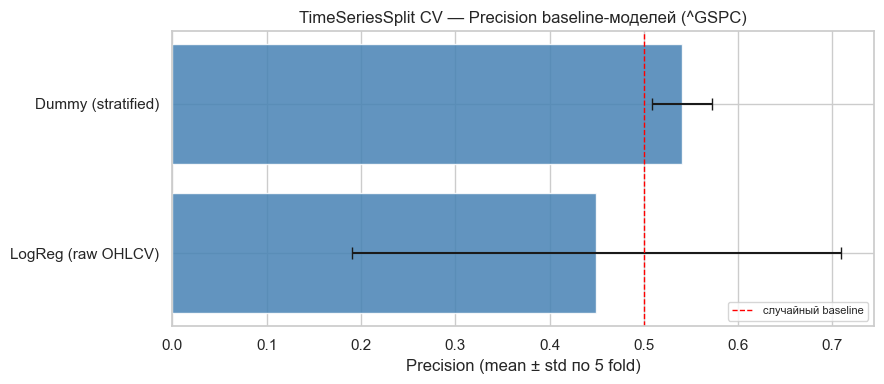

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ordered = cv_results.sort_values('precision_mean')
ax.barh(
    ordered.index, ordered['precision_mean'],
    xerr=ordered['precision_std'], color='steelblue', alpha=0.85, capsize=4,
)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='случайный baseline')
ax.set_xlabel('Precision (mean ± std по 5 fold)')
ax.set_title(f'TimeSeriesSplit CV — Precision baseline-моделей ({PRIMARY})')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 4. Кросс-тикерная проверка

Запускаем holdout на всех 5 тикерах. Если baseline где-то «случайно» хорош — это шум одного актива, а не общая закономерность.

In [8]:
cross_ticker = []
for t in TICKERS:
    res = run_baseline_holdout(t, START, END, random_state=RANDOM_SEED)
    res = res[['precision', 'roc_auc']].copy()
    res.columns = pd.MultiIndex.from_product([[t], res.columns])
    cross_ticker.append(res)
cross_ticker_df = pd.concat(cross_ticker, axis=1)
cross_ticker_df.round(4)

^GSPC              AAPL              MSFT          \
                   precision roc_auc precision roc_auc precision roc_auc   
model                                                                      
Dummy (stratified)    0.4926  0.5061    0.5211  0.5105    0.5412  0.5389   
LogReg (raw OHLCV)    0.4914  0.4814    0.4986  0.4695    0.5031  0.5107   

                         JPM               XOM          
                   precision roc_auc precision roc_auc  
model                                                   
Dummy (stratified)    0.5203  0.5033    0.5216  0.4884  
LogReg (raw OHLCV)    0.5000  0.4497    0.5854  0.5178

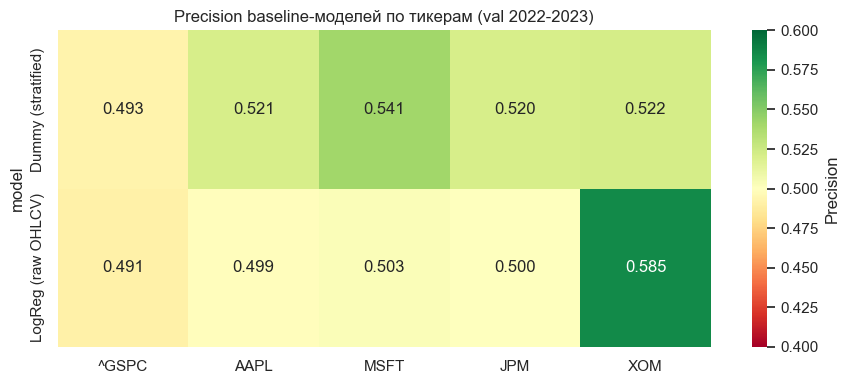

In [9]:
precision_matrix = pd.DataFrame({
    t: cross_ticker_df[(t, 'precision')] for t in TICKERS
})
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    precision_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0.5, vmin=0.4, vmax=0.6, cbar_kws={'label': 'Precision'}, ax=ax,
)
ax.set_title('Precision baseline-моделей по тикерам (val 2022-2023)')
plt.tight_layout(); plt.show()

## 5. Выводы

**Что показал baseline на сырых OHLCV.**

1. **Precision ≈ class balance.** На holdout все модели зажаты в окрестности `mean(Target)` (~0.49-0.54 в зависимости от тикера). Ни одна модель не превышает Dummy(majority) на статистически значимую величину. Это ожидаемо: сырые цены нестационарны (см. EDA, раздел 6), линейные/расстояние-based модели работают на абсолютных уровнях, которые в test-периоде сильно отличаются от train.

2. **ROC-AUC ≈ 0.5.** Подтверждение того же — модели не разделяют классы лучше случайного.

3. **CV-разброс высокий.** TimeSeriesSplit показывает, что `precision_std` сравним с `precision_mean`: модель «угадывает» по-разному в зависимости от режима (бычий 2017, COVID 2020, инфляция 2022). Без feature engineering сигнал отсутствует.

4. **trade_freq нестабильна.** LogReg на нестационарных данных в зависимости от fold'а торгует то в 0%, то в 100% дней — это явный признак того, что разделяющая гиперплоскость летит вместе с ценой.

**Что это означает для `03_experiments`.**

Любая модель с 9 фичами из `src/preprocessing.py` (RSI, MACD, Bollinger %B и т.д.) должна заметно обойти эти числа — иначе фичи бесполезны. Целевой ориентир для следующего этапа: Precision ≥ 0.55 на val при trade_freq ≥ 0.2 (стратегия должна реально торговать).